In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score

In [19]:
torch.serialization.add_safe_globals([np._core.multiarray._reconstruct])

In [53]:
data = torch.load("cognitive_load_dataset_2.pt", weights_only=False)

X = data["X"]
y = data["y"]
participants = data["participant"]

print(X.shape)
print(y.shape)
print(participants.shape)

(13609, 400, 7)
(13609,)
(13609,)


In [54]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [55]:
print(len(participants))

13609


In [56]:
X_mean = X.mean(axis=1)
X_std = X.std(axis=1)

X_features = np.concatenate(
    [X_mean, X_std],
    axis=1
)

print(X_features.shape)

(13609, 14)


In [57]:
unique_participants = np.unique(participants)

# Using the last 5 participants for testing
train_subjects = unique_participants[:-5]
test_subjects = unique_participants[-5:]

train_mask = np.isin(participants, train_subjects)
test_mask = np.isin(participants, test_subjects)

unique_participants

array([13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
       31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47])

In [58]:
X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

In [59]:
X_train_features = X_features[train_mask]
X_test_features = X_features[test_mask]

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

In [61]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    max_iter=1000
)

clf.fit(
    X_train_scaled,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [62]:
pred = clf.predict(X_test_scaled)

print(
    accuracy_score(
        y_test,
        pred
    )
)

0.8509485094850948


In [63]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(
    X_train_features,
    y_train
)

pred = rf.predict(
    X_test_features
)

print(
    accuracy_score(
        y_test,
        pred
    )
)

0.8762420957542909


In [64]:
for i, importance in enumerate(rf.feature_importances_):
    print(i, importance)

0 0.09877483188381231
1 0.10232947698040838
2 0.030008125433183683
3 0.061864508817656656
4 0.04349577882195615
5 0.03182328787686055
6 0.03276403270756768
7 0.041131165649848075
8 0.06163878303639836
9 0.04820752786425469
10 0.08310136508302697
11 0.2474964001540573
12 0.04003243216591786
13 0.07733228352505124


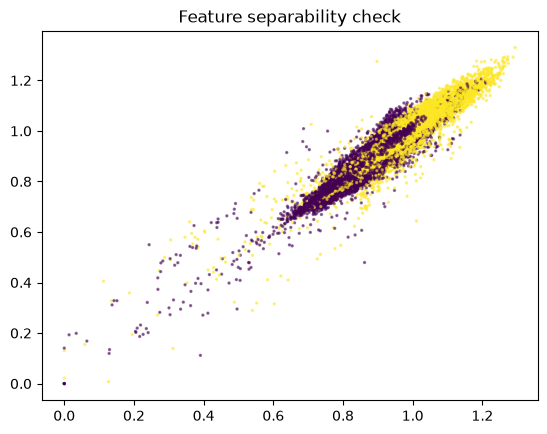

In [65]:
import matplotlib.pyplot as plt

plt.scatter(
    X_features[:, 0],
    X_features[:, 1],
    c=y,
    s=2,
    alpha=0.5
)

plt.title("Feature separability check")
plt.show()

In [66]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_dataset = TensorDataset(
    X_train,
    y_train
)

test_dataset = TensorDataset(
    X_test,
    y_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [67]:
class CognitiveLoadLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        output, (hn, cn) = self.lstm(x)

        last_hidden = hn[-1]

        logits = self.classifier(last_hidden)

        return logits.squeeze(1)

In [68]:
input_size = X.shape[2]

model = CognitiveLoadLSTM(
    input_size=input_size
)

In [69]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [70]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [71]:
model.to(device)

EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)

        loss = criterion(
            logits,
            y_batch
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"{total_loss:.4f}"
    )
    epoch_loss = total_loss / len(train_loader)
    print(epoch_loss)

Epoch 1: 116.2829
0.6496250759289918
Epoch 2: 111.7777
0.6244564411027471
Epoch 3: 105.4244
0.5889631521435423
Epoch 4: 111.4897
0.6228477312199896
Epoch 5: 100.4982
0.5614422166813685
Epoch 6: 100.9747
0.5641046349562746
Epoch 7: 104.3214
0.5828013616567217
Epoch 8: 111.4015
0.6223544914629207
Epoch 9: 120.7244
0.6744378299020523
Epoch 10: 114.9136
0.6419754084928075
Epoch 11: 105.5215
0.5895057137452024
Epoch 12: 109.3397
0.6108365654945374
Epoch 13: 106.5253
0.5951136269049937
Epoch 14: 91.7203
0.5124038730919694
Epoch 15: 90.4168
0.5051219070423915
Epoch 16: 89.2239
0.4984577512940881
Epoch 17: 98.4551
0.5500284921190592
Epoch 18: 87.2264
0.487298150468805
Epoch 19: 78.4623
0.43833661920198513
Epoch 20: 84.1048
0.4698593190262437


In [39]:
print(torch.bincount(y.long()))

tensor([14249, 13183])


In [40]:
print(X.shape)
print(X.mean())
print(X.std())
print(X.min())
print(X.max())

torch.Size([27432, 400, 7])
tensor(0.6665)
tensor(0.4456)
tensor(-0.9566)
tensor(2.1090)


In [72]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        logits = model(X_batch)

        probs = torch.sigmoid(logits)

        preds = (
            probs > 0.5
        ).cpu().numpy()

        predictions.extend(preds)

        targets.extend(
            y_batch.numpy()
        )

accuracy = accuracy_score(
    targets,
    predictions
)

print(
    f"Accuracy: {accuracy:.3f}"
)

Accuracy: 0.794


In [74]:
print(X.shape)

torch.Size([13609, 400, 7])


In [77]:
dummy_input = torch.randn(
    1,
    X.shape[1],
    X.shape[2]
).to(device)

model.eval()
with torch.no_grad():
    out = model(dummy_input)
    print(out.shape)

torch.Size([1])


In [79]:
onnx_program = torch.onnx.export(
    model,
    dummy_input,
    "cognitive_load_lstm.onnx",
    input_names=["input"],
    output_names=["output"],
    dynamic_axes=None,
    # dynamic_axes={
    #     "input": {0: "batch"},
    #     "output": {0: "batch"}
    # },
    # opset_version=13
    dynamo=True
)

onnx_program.save("CL_classifier_model.onnx")

[torch.onnx] Obtain model graph for `CognitiveLoadLSTM([...]` with `torch.export.export(..., strict=False)`...


c:\Users\gadel\AppData\Local\Python\pythoncore-3.14-64\Lib\contextlib.py:148: UserWarning: The tensor attributes self.lstm._flat_weights[0], self.lstm._flat_weights[1], self.lstm._flat_weights[2], self.lstm._flat_weights[3], self.lstm._flat_weights[4], self.lstm._flat_weights[5], self.lstm._flat_weights[6], self.lstm._flat_weights[7] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `CognitiveLoadLSTM([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\gadel\AppData\Local\Python\pythoncore-3.14-64\Lib\copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
